In [22]:
from pathlib import Path
import requests

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [25]:
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print('Device:', DEVICE)

Device: mps


In [27]:
BATCH_SIZE = 64
SEQ_LEN = 100
STRIDE = SEQ_LEN          # non-overlapping training windows

EMBED_SIZE = 128
HIDDEN_SIZE = 256

LEARNING_RATE = 0.002
EPOCHS = 20

TEMPERATURE = 0.8

torch.manual_seed(42)

In [28]:
URL = (
    "https://raw.githubusercontent.com/"
    "karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
)

DATA_PATH = Path("tinyshakespeare.txt")

if not DATA_PATH.exists():
    print("Downloading dataset...")
    response = requests.get(URL, timeout=30)
    response.raise_for_status()
    DATA_PATH.write_text(response.text, encoding="utf-8")

text = DATA_PATH.read_text(encoding="utf-8")

print("Number of characters:", len(text))

Number of characters: 1115394


In [29]:
print(text[:300])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


In [ ]:
chars = sorted(set(text))
vocab_size = len(chars)

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

print("Vocabulary size:", vocab_size)
print("Characters:", "".join(chars))

Vocabulary size: 65
Characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz


In [31]:
def encode(s):
    return [stoi[c] for c in s]

def decode(indices):
    return "".join(itos[i] for i in indices)

print(encode('ROMEO:'))
print(decode(encode('ROMEO:')))

[30, 27, 25, 17, 27, 10]
ROMEO:


In [32]:
data = torch.tensor(encode(text), dtype=torch.long)

split = int(0.9 * len(data))
train_data = data[:split]
val_data = data[split:]

print("Encoded data shape:", tuple(data.shape))
print("Train characters:", len(train_data))
print("Validation characters:", len(val_data))

Encoded data shape: (1115394,)
Train characters: 1003854
Validation characters: 111540


In [33]:
class CharDataset(Dataset):

    def __init__(self, data, seq_len, stride):
        self.data = data
        self.seq_len = seq_len
        self.stride = stride
        self.n_samples = (len(data) - seq_len - 1) // stride + 1

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        start = idx * self.stride
        x = self.data[start:start + self.seq_len]
        y = self.data[start + 1:start + self.seq_len + 1]
        return x, y

In [34]:
train_dataset = CharDataset(train_data, SEQ_LEN, STRIDE)
val_dataset = CharDataset(val_data, SEQ_LEN, STRIDE)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=True,
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 156
Validation batches: 17


In [35]:
x_batch, y_batch = next(iter(train_loader))

print("x:", tuple(x_batch.shape))
print("y:", tuple(y_batch.shape))
print("\ninput :", repr(decode(x_batch[0, :40].tolist())))
print("target:", repr(decode(y_batch[0, :40].tolist())))

x: (64, 100)
y: (64, 100)

input : ' the demigod Authority\nMake us pay down '
target: 'the demigod Authority\nMake us pay down f'


In [37]:
class VanillaRNN(nn.Module):

    def __init__(self, vocab_size, embed_size, hidden_size):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_size)

        self.rnn = nn.RNN(
            input_size = embed_size, 
            hidden_size = hidden_size,
            num_layers = 1,
            batch_first = True,
            nonlinearity = "tanh"
            )

        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden = None):
        x = self.embedding(x)
        output, hidden = self.rnn(x, hidden)
        logits = self.fc(output)
        return logits, hidden
        

In [38]:
model = VanillaRNN(
    vocab_size = vocab_size, 
    embed_size = EMBED_SIZE, 
    hidden_size = HIDDEN_SIZE
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())

print(model)

print(total_params)

VanillaRNN(
  (embedding): Embedding(65, 128)
  (rnn): RNN(128, 256, batch_first=True)
  (fc): Linear(in_features=256, out_features=65, bias=True)
)
123841


In [39]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = LEARNING_RATE)

In [40]:
def train_one_epoch():
    model.train()
    total_loss = 0.0

    for x, y in train_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad()

        logits, _ = model(x)
        loss = criterion(logits.reshape(-1, vocab_size), y.reshape(-1))
        loss.backward()

        # vanilla RNNs are prone to exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

In [41]:
@torch.no_grad()
def evaluate():
    model.eval()
    total_loss = 0.0

    for x, y in val_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        logits, _ = model(x)
        loss = criterion(logits.reshape(-1, vocab_size), y.reshape(-1))

        total_loss += loss.item()

    return total_loss / len(val_loader)

In [42]:
train_losses = []
val_losses = []

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch()
    val_loss = evaluate()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch:02d}/{EPOCHS}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Val Loss: {val_loss:.4f}"
    )


Epoch [01/20] | Train Loss: 2.1960 | Val Loss: 1.9469
Epoch [02/20] | Train Loss: 1.7661 | Val Loss: 1.8122
Epoch [03/20] | Train Loss: 1.6441 | Val Loss: 1.7583
Epoch [04/20] | Train Loss: 1.5802 | Val Loss: 1.7085
Epoch [05/20] | Train Loss: 1.5399 | Val Loss: 1.6817
Epoch [06/20] | Train Loss: 1.5115 | Val Loss: 1.6664
Epoch [07/20] | Train Loss: 1.4901 | Val Loss: 1.6570
Epoch [08/20] | Train Loss: 1.4734 | Val Loss: 1.6459
Epoch [09/20] | Train Loss: 1.4590 | Val Loss: 1.6311
Epoch [10/20] | Train Loss: 1.4472 | Val Loss: 1.6320
Epoch [11/20] | Train Loss: 1.4378 | Val Loss: 1.6263
Epoch [12/20] | Train Loss: 1.4289 | Val Loss: 1.6227
Epoch [13/20] | Train Loss: 1.4217 | Val Loss: 1.6152
Epoch [14/20] | Train Loss: 1.4153 | Val Loss: 1.6105
Epoch [15/20] | Train Loss: 1.4089 | Val Loss: 1.6072
Epoch [16/20] | Train Loss: 1.4039 | Val Loss: 1.6067
Epoch [17/20] | Train Loss: 1.3993 | Val Loss: 1.6063
Epoch [18/20] | Train Loss: 1.3948 | Val Loss: 1.6058
Epoch [19/20] | Train Loss: 

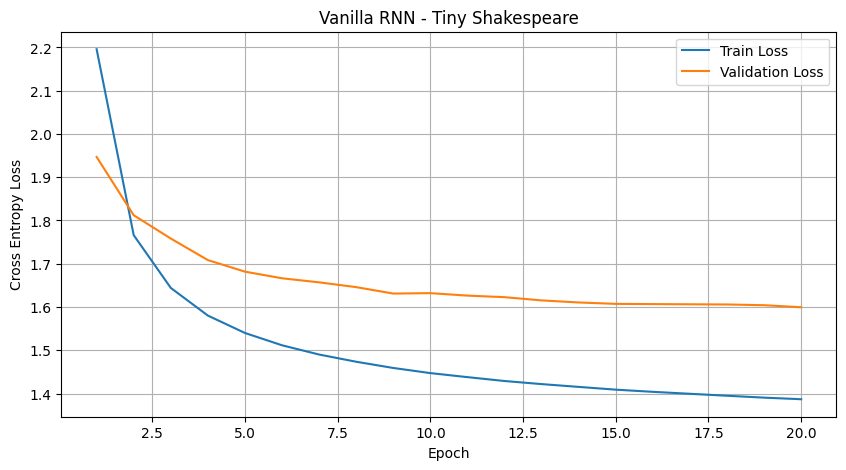

In [43]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS + 1), train_losses, label="Train Loss")
plt.plot(range(1, EPOCHS + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.title("Vanilla RNN - Tiny Shakespeare")
plt.legend()
plt.grid(True)
plt.show()

In [44]:
@torch.no_grad()
def generate_text(prompt, max_new_tokens=500, temperature=0.8):
    model.eval()

    input_ids = torch.tensor(
        encode(prompt), dtype=torch.long, device=DEVICE
    ).unsqueeze(0)   # [1, seq_len]

    hidden = None

    if input_ids.shape[1] > 1:
        _, hidden = model(input_ids[:, :-1], hidden)

    current = input_ids[:, -1:]
    generated = prompt

    for _ in range(max_new_tokens):
        logits, hidden = model(current, hidden)

        logits = logits[:, -1, :] / temperature
        probabilities = F.softmax(logits, dim=-1)

        next_char = torch.multinomial(probabilities, num_samples=1)

        generated += itos[next_char.item()]
        current = next_char

    return generated

In [45]:
print(generate_text("ROMEO:", max_new_tokens=200, temperature=TEMPERATURE))

ROMEO:
O hate it well bearing some cales it to the some strong in the need undrant to the prince do never of a vow,
To be world;
We have seen the extrefes above you am could speak of notel as they be
so las


In [46]:
checkpoint_path = "vanilla_rnn_shakespeare.pt"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "stoi": stoi,
        "itos": itos,
        "vocab_size": vocab_size,
        "embed_size": EMBED_SIZE,
        "hidden_size": HIDDEN_SIZE,
    },
    checkpoint_path,
)

print("Model saved to:", checkpoint_path)

Model saved to: vanilla_rnn_shakespeare.pt
